# 01.02 · Árboles, bosques y boosting (el ML que le gana al DL en tablas)

**Objetivo:** entender de forma práctica la familia de modelos que domina los
**datos tabulares** —árboles de decisión, Random Forest, gradient boosting y
XGBoost/LightGBM— y **comprobar experimentalmente** las afirmaciones teóricas
de la nota `docs/01-fundamentos/01-que-es-y-de-donde-viene/1.2`.

No es un notebook de "llamar a `.fit()`". Cada sección verifica una afirmación:

| § | Afirmación que vamos a comprobar | De la teoría |
|---|---|---|
| 3 | Un árbol solo memoriza: la profundidad controla sesgo vs varianza | 1.2.1 |
| 4 | El *bagging* reduce la varianza promediando árboles decorrelacionados | 1.2.3 |
| 5 | **El gradient boosting ES descenso de gradiente** (lo implementamos a mano) | 1.2.3 |
| 6 | Los árboles cortan en **escalones**; las redes **suavizan** | 1.2.4 |
| 7 | **Los árboles NO extrapolan** (el límite que casi nadie cuenta) | 1.2.4 |
| 8 | En datos **limpios** el boosting NO gana en métrica... pero cuesta 20× menos | 1.2.5 |
| 8-bis | ...y en datos **irregulares** (nulos, categóricas, sesgo) sí gana claramente | 1.2.5 |
| 9 | Se puede explicar una predicción individual (obligación legal) | 1.2.7 |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/labs/dl-lab/notebooks/01-fundamentos/01-que-es-y-de-donde-viene/01_02_arboles_bosques_y_boosting.ipynb)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

# Las librerías de boosting no venían en la imagen original del lab: si faltan,
# se instalan al vuelo (así el notebook corre sin reconstruir el contenedor).
for _pkg in ("xgboost", "lightgbm"):
    if importlib.util.find_spec(_pkg) is None:
        print(f"Instalando {_pkg}...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import time

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

from dllab import set_seed

set_seed(42)
RNG = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (11, 4)
print(f"xgboost {xgb.__version__} · lightgbm {lgb.__version__}")

xgboost 3.2.0 · lightgbm 4.7.0


## 1. El dataset: un *scoring* de crédito con reglas de negocio explícitas

Generamos datos sintéticos **a propósito**, porque así conocemos la verdad
oculta y podemos comprobar si cada modelo la recupera. Es exactamente el
ejemplo de la sección 1.2.7 de la teoría.

La regla real que gobierna el impago es **escalonada** (umbrales duros), como
casi cualquier regla de negocio:

```
impago = 1  si  (ratio_deuda > 0.40)  Y  (antiguedad < 3)
         1  si  (historico_impagos == 1) Y (ingresos < 30.000)
         0  en el resto            (+ 8 % de ruido aleatorio)
```

In [3]:
def generar_datos_credito(n=8000, ruido=0.08, seed=42):
    """Dataset tabular sintético con reglas de negocio ESCALONADAS y 3 columnas irrelevantes."""
    rng = np.random.default_rng(seed)
    df = pd.DataFrame(
        {
            "ingresos_anuales": rng.normal(35_000, 12_000, n).clip(8_000, 120_000),
            "ratio_deuda_ingresos": rng.beta(2, 5, n),
            "historico_impagos": rng.binomial(1, 0.18, n),
            "antiguedad_laboral_anos": rng.exponential(4, n).clip(0, 40),
            # --- ruido puro: no influyen en el objetivo (ver §9) ---
            "ruido_1": rng.normal(0, 1, n),
            "ruido_2": rng.uniform(0, 100, n),
            "ruido_3": rng.integers(0, 5, n),
        }
    )
    regla = (
        (df.ratio_deuda_ingresos > 0.40) & (df.antiguedad_laboral_anos < 3)
    ) | ((df.historico_impagos == 1) & (df.ingresos_anuales < 30_000))
    y = regla.astype(int).to_numpy()
    volteo = rng.random(n) < ruido  # ruido irreducible: ningún modelo puede pasar de aquí
    y[volteo] = 1 - y[volteo]
    return df, y


X_df, y = generar_datos_credito()
X_tr, X_te, y_tr, y_te = train_test_split(X_df, y, test_size=0.25, random_state=42, stratify=y)

print(f"Entrenamiento: {X_tr.shape}  ·  Test: {X_te.shape}")
print(f"Tasa de impago: {y.mean():.1%}")
print("\nTecho teórico de precisión ≈ 92 % (hay un 8 % de ruido irreducible)")
X_df.head()

Entrenamiento: (6000, 7)  ·  Test: (2000, 7)
Tasa de impago: 23.0%

Techo teórico de precisión ≈ 92 % (hay un 8 % de ruido irreducible)


,ingresos_anuales,ratio_deuda_ingresos,historico_impagos,antiguedad_laboral_anos,ruido_1,ruido_2,ruido_3
0,38656.604957,0.338380,1,1.122893,0.744690,94.169890,1
1,22520.190725,0.405285,1,0.223140,-0.277893,43.117170,2
2,44005.414350,0.306968,0,1.185262,-1.512986,79.838419,0
3,46286.776597,0.106286,0,4.012705,1.725820,71.543589,0
4,11587.577736,0.323762,1,12.335018,-0.993219,67.106507,3


## 2. Un árbol de decisión: el único modelo que se puede *leer*

Entrenamos un árbol muy poco profundo y lo imprimimos como reglas. Compara la
salida con la regla real de arriba: **la recupera casi literalmente**.

In [4]:
arbol_simple = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)

print(export_text(arbol_simple, feature_names=list(X_df.columns), max_depth=3))
print(f"Accuracy test: {arbol_simple.score(X_te, y_te):.3f}")

|--- ratio_deuda_ingresos <= 0.40
|   |--- historico_impagos <= 0.50
|   |   |--- ruido_2 <= 22.06
|   |   |   |--- class: 0
|   |   |--- ruido_2 >  22.06
|   |   |   |--- class: 0
|   |--- historico_impagos >  0.50
|   |   |--- ingresos_anuales <= 30123.67
|   |   |   |--- class: 1
|   |   |--- ingresos_anuales >  30123.67
|   |   |   |--- class: 0
|--- ratio_deuda_ingresos >  0.40
|   |--- antiguedad_laboral_anos <= 3.00
|   |   |--- antiguedad_laboral_anos <= 2.68
|   |   |   |--- class: 1
|   |   |--- antiguedad_laboral_anos >  2.68
|   |   |   |--- class: 1
|   |--- antiguedad_laboral_anos >  3.00
|   |   |--- historico_impagos <= 0.50
|   |   |   |--- class: 0
|   |   |--- historico_impagos >  0.50
|   |   |   |--- class: 0

Accuracy test: 0.922


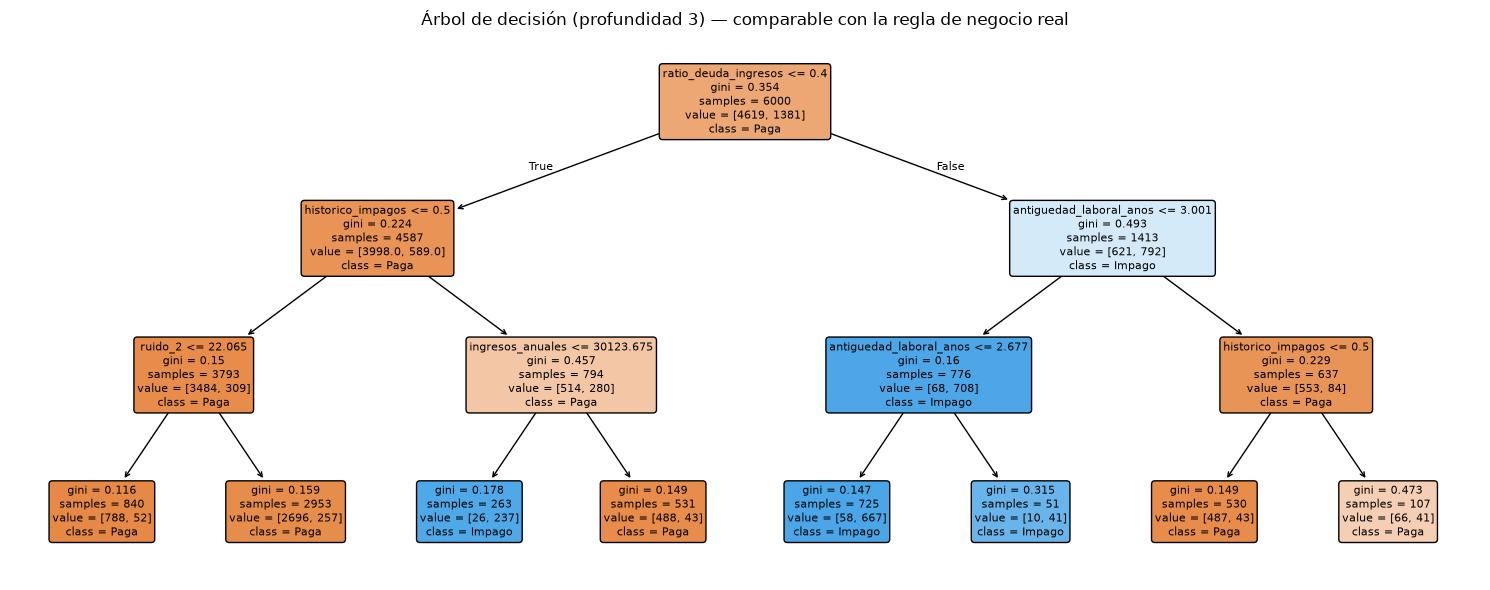

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(
    arbol_simple,
    feature_names=list(X_df.columns),
    class_names=["Paga", "Impago"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Árbol de decisión (profundidad 3) — comparable con la regla de negocio real")
plt.tight_layout()
plt.show()

## 3. Sesgo vs varianza: por qué un árbol solo no basta

Barremos la profundidad y medimos error en **entrenamiento** y en **test**. Es
la curva de sobreajuste más clara que existe: el árbol acaba **memorizando**
el ruido (accuracy de entrenamiento → 1.0) mientras el test empeora.

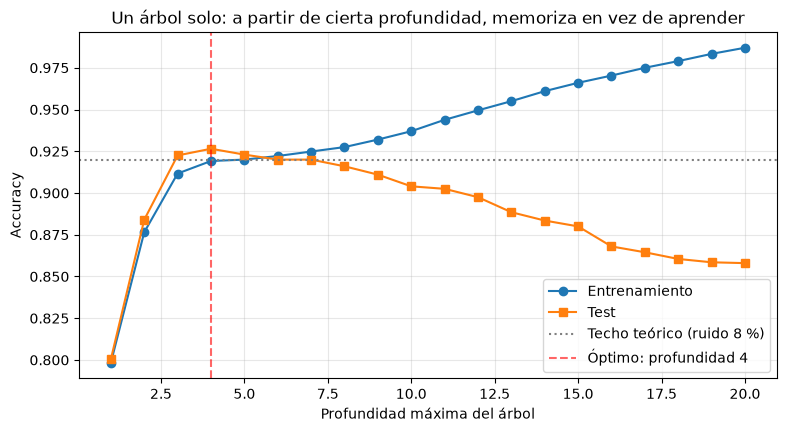

Profundidad óptima: 4 · accuracy test 0.926
Profundidad 20   : accuracy train 0.987 vs test 0.858  ← sobreajuste


In [6]:
profundidades = range(1, 21)
acc_tr, acc_te = [], []
for d in profundidades:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_tr, y_tr)
    acc_tr.append(m.score(X_tr, y_tr))
    acc_te.append(m.score(X_te, y_te))

mejor_d = profundidades[int(np.argmax(acc_te))]

plt.figure(figsize=(9, 4.5))
plt.plot(profundidades, acc_tr, "o-", label="Entrenamiento")
plt.plot(profundidades, acc_te, "s-", label="Test")
plt.axhline(0.92, ls=":", c="gray", label="Techo teórico (ruido 8 %)")
plt.axvline(mejor_d, ls="--", c="red", alpha=0.6, label=f"Óptimo: profundidad {mejor_d}")
plt.xlabel("Profundidad máxima del árbol")
plt.ylabel("Accuracy")
plt.title("Un árbol solo: a partir de cierta profundidad, memoriza en vez de aprender")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Profundidad óptima: {mejor_d} · accuracy test {max(acc_te):.3f}")
print(f"Profundidad 20   : accuracy train {acc_tr[-1]:.3f} vs test {acc_te[-1]:.3f}  ← sobreajuste")

## 4. Bagging = Random Forest: promediar para reducir la varianza

La idea (1.2.3): entrenar muchos árboles **profundos** (alta varianza, bajo
sesgo) sobre muestras distintas de filas y columnas, y promediar. La varianza
se cancela; el sesgo no sube.

Demostración: un árbol profundo suelto tiene mucha varianza entre semillas.
Un bosque, casi ninguna.

In [7]:
var_arbol = [
    DecisionTreeClassifier(max_depth=None, random_state=s).fit(X_tr, y_tr).score(X_te, y_te)
    for s in range(10)
]
var_bosque = [
    RandomForestClassifier(n_estimators=100, random_state=s, n_jobs=-1)
    .fit(X_tr, y_tr)
    .score(X_te, y_te)
    for s in range(10)
]

print(f"Árbol profundo suelto → media {np.mean(var_arbol):.4f} · desv. {np.std(var_arbol):.4f}")
print(f"Random Forest (100)   → media {np.mean(var_bosque):.4f} · desv. {np.std(var_bosque):.4f}")
print(f"\nLa varianza se reduce ~{np.std(var_arbol) / max(np.std(var_bosque), 1e-9):.0f}× "
      f"y además la media SUBE. Eso es bagging.")

Árbol profundo suelto → media 0.8408 · desv. 0.0035
Random Forest (100)   → media 0.9273 · desv. 0.0004

La varianza se reduce ~9× y además la media SUBE. Eso es bagging.


## 5. Gradient boosting a mano: la prueba de que **es descenso de gradiente**

Esta es la celda clave del notebook. Implementamos boosting desde cero en ~15
líneas para verificar la afirmación de 1.2.3: cada árbol nuevo **no** predice
el objetivo, predice **el error que queda** (el residuo). Y el residuo del
error cuadrático es, literalmente, el gradiente negativo de la pérdida.

$$ \mathcal{L} = \tfrac{1}{2}(y - F(x))^2 \quad\Longrightarrow\quad
   -\frac{\partial \mathcal{L}}{\partial F} = y - F(x) = \text{residuo} $$

Mismo bucle que entrenar una red (→ docs 1.1.2): *mide el error → ve en qué
dirección corregir → da un paso pequeño (`η`) → repite*. La única diferencia
es que aquí el paso **suma una función nueva** en vez de mover parámetros.

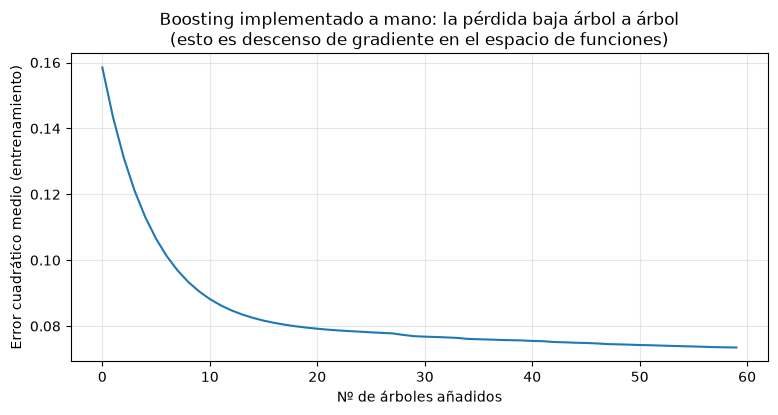

MSE inicial (solo la media): 0.1585
MSE tras 60 árboles       : 0.0735
Accuracy en test de NUESTRO boosting artesanal: 0.924


In [8]:
def boosting_desde_cero(X, y, n_arboles=60, eta=0.1, max_depth=3):
    """Gradient boosting con pérdida cuadrática, en su forma más desnuda."""
    F = np.full(len(y), y.mean())  # predicción_0 = la media global
    arboles, historial = [], []

    for _ in range(n_arboles):
        residuos = y - F  # <-- el gradiente negativo de la pérdida
        t = DecisionTreeRegressor(max_depth=max_depth, random_state=42).fit(X, residuos)
        F = F + eta * t.predict(X)  # <-- un paso pequeño en esa dirección
        arboles.append(t)
        historial.append(np.mean((y - F) ** 2))

    return arboles, historial


def predecir_boosting(arboles, X, y_media, eta=0.1):
    F = np.full(len(X), y_media)
    for t in arboles:
        F += eta * t.predict(X)
    return F


arboles, historial = boosting_desde_cero(X_tr.to_numpy(), y_tr.astype(float))

probs = predecir_boosting(arboles, X_te.to_numpy(), y_tr.mean())
acc_manual = accuracy_score(y_te, (probs > 0.5).astype(int))

plt.figure(figsize=(9, 4))
plt.plot(historial)
plt.xlabel("Nº de árboles añadidos")
plt.ylabel("Error cuadrático medio (entrenamiento)")
plt.title("Boosting implementado a mano: la pérdida baja árbol a árbol\n"
          "(esto es descenso de gradiente en el espacio de funciones)")
plt.grid(alpha=0.3)
plt.show()

print(f"MSE inicial (solo la media): {historial[0]:.4f}")
print(f"MSE tras 60 árboles       : {historial[-1]:.4f}")
print(f"Accuracy en test de NUESTRO boosting artesanal: {acc_manual:.3f}")

### Contraste: nuestro boosting artesanal vs las librerías reales

Las tres librerías industriales hacen exactamente lo mismo que acabamos de
programar; lo que añaden es **ingeniería**, no teoría distinta (1.2.3):
regularización, histogramas para acelerar los cortes, manejo nativo de nulos
y de variables categóricas, y paralelismo.

In [9]:
modelos = {
    "Árbol (prof. óptima)": DecisionTreeClassifier(max_depth=mejor_d, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting (sklearn)": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=5,
        eval_metric="logloss", random_state=42, n_jobs=-1,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1
    ),
}

filas = []
for nombre, modelo in modelos.items():
    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    t_fit = time.perf_counter() - t0

    t0 = time.perf_counter()
    pred = modelo.predict(X_te)
    t_pred = (time.perf_counter() - t0) * 1000

    proba = modelo.predict_proba(X_te)[:, 1]
    filas.append(
        {
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_te, pred),
            "ROC-AUC": roc_auc_score(y_te, proba),
            "Entrenar (s)": round(t_fit, 3),
            "Inferir 2k filas (ms)": round(t_pred, 1),
        }
    )

resultados = pd.DataFrame(filas).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
resultados

,Modelo,Accuracy,ROC-AUC,Entrenar (s),Inferir 2k filas (ms)
0,GradientBoosting (sklearn),0.9275,0.874191,0.712,3.9
1,Random Forest,0.9280,0.871412,0.579,51.3
2,Árbol (prof. óptima),0.9265,0.870758,0.016,2.1
3,XGBoost,0.9255,0.869327,0.661,8.4
4,LightGBM,0.9250,0.863156,0.406,12.8


## 6. Fronteras de decisión: escalones vs curvas

Comprobación visual de la segunda razón de 1.2.4. Usamos `make_moons` (2D para
poder dibujarlo) y comparamos cómo parte el espacio cada familia.

Fíjate: los árboles producen **rectángulos con bordes ortogonales a los ejes**;
la red neuronal produce una **curva suave**. Ninguna forma es mejor en abstracto
— la buena es la que se parezca a la verdad del problema. En datos tabulares con
reglas de negocio, la verdad tiene forma de escalón.

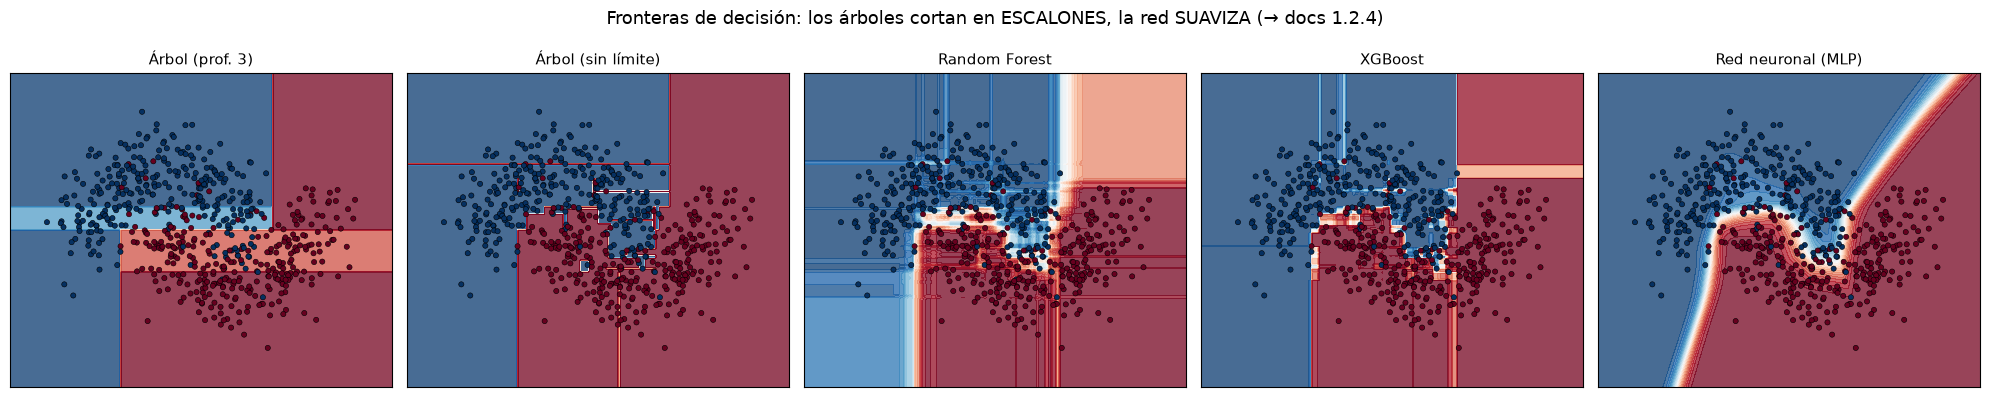

In [10]:
Xm, ym = make_moons(n_samples=600, noise=0.28, random_state=42)

comparacion = {
    "Árbol (prof. 3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Árbol (sin límite)": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42),
    "Red neuronal (MLP)": make_pipeline(
        StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=2000, random_state=42)
    ),
}

xx, yy = np.meshgrid(
    np.linspace(Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5, 300),
    np.linspace(Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5, 300),
)
malla = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (nombre, modelo) in zip(axes, comparacion.items()):
    modelo.fit(Xm, ym)
    Z = modelo.predict_proba(malla)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=25, cmap="RdBu_r", alpha=0.75)
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="RdBu_r", edgecolors="k", s=14, linewidths=0.4)
    ax.set_title(nombre, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Fronteras de decisión: los árboles cortan en ESCALONES, la red SUAVIZA (→ docs 1.2.4)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 7. El límite que casi nadie cuenta: **los árboles no extrapolan**

Verificación del recuadro de aviso de 1.2.4. Un árbol predice en cada hoja una
**constante** aprendida del entrenamiento, así que **jamás puede devolver un
valor fuera del rango que vio**.

Entrenamos con `x ∈ [0, 10]` sobre una recta con ruido y predecimos hasta
`x = 20`. El árbol y XGBoost se quedan **planos**; la regresión lineal sigue.
Para series temporales con tendencia, esto descalifica a los árboles.

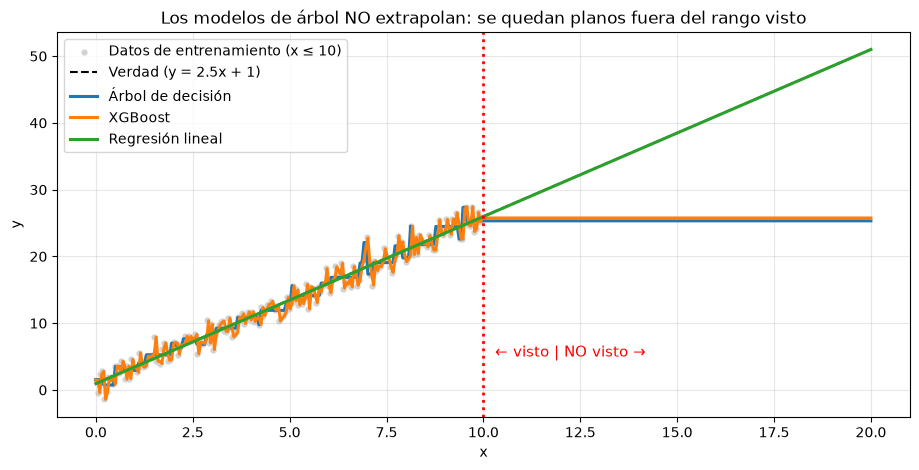

Árbol de decisión    → predicción en x=20:   25.33   (real: 51.00)
XGBoost              → predicción en x=20:   25.75   (real: 51.00)
Regresión lineal     → predicción en x=20:   51.00   (real: 51.00)


In [11]:
from sklearn.linear_model import LinearRegression  # noqa: E402

x_tr = np.linspace(0, 10, 200).reshape(-1, 1)
y_tr_reg = 2.5 * x_tr.ravel() + 1.0 + RNG.normal(0, 1.5, 200)
x_full = np.linspace(0, 20, 400).reshape(-1, 1)
y_real = 2.5 * x_full.ravel() + 1.0

extrapoladores = {
    "Árbol de decisión": DecisionTreeRegressor(max_depth=5, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, random_state=42),
    "Regresión lineal": LinearRegression(),
}

plt.figure(figsize=(11, 5))
plt.scatter(x_tr, y_tr_reg, s=12, c="lightgray", label="Datos de entrenamiento (x ≤ 10)")
plt.plot(x_full, y_real, "k--", lw=1.5, label="Verdad (y = 2.5x + 1)")
for nombre, m in extrapoladores.items():
    m.fit(x_tr, y_tr_reg)
    plt.plot(x_full, m.predict(x_full), lw=2.2, label=nombre)

plt.axvline(10, color="red", ls=":", lw=2)
plt.text(10.3, 5, "← visto | NO visto →", color="red", fontsize=11)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Los modelos de árbol NO extrapolan: se quedan planos fuera del rango visto")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

for nombre, m in extrapoladores.items():
    print(f"{nombre:20s} → predicción en x=20: {m.predict([[20.0]])[0]:7.2f}   (real: 51.00)")

## 8. El experimento principal: boosting vs red neuronal en datos tabulares

La afirmación de 1.2.5, medida de verdad. Damos a la red neuronal un trato
**justo**: normalizamos las entradas (los árboles no lo necesitan, son
invariantes a transformaciones monótonas) y le damos capacidad de sobra.

Medimos las dos cosas que importan en producción: **métrica** y **coste**.

In [12]:
competidores = {
    "XGBoost (por defecto)": xgb.XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM (por defecto)": lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "MLP pequeña (64,32)": make_pipeline(
        StandardScaler(), MLPClassifier((64, 32), max_iter=1500, random_state=42)
    ),
    "MLP grande (256,128,64)": make_pipeline(
        StandardScaler(), MLPClassifier((256, 128, 64), max_iter=1500, random_state=42)
    ),
}

filas = []
for nombre, modelo in competidores.items():
    t0 = time.perf_counter()
    auc = cross_val_score(modelo, X_df, y, cv=5, scoring="roc_auc", n_jobs=1)
    filas.append(
        {
            "Modelo": nombre,
            "ROC-AUC (media 5-fold)": auc.mean().round(4),
            "Desv.": auc.std().round(4),
            "Tiempo total (s)": round(time.perf_counter() - t0, 2),
        }
    )

comparativa = pd.DataFrame(filas).sort_values("ROC-AUC (media 5-fold)", ascending=False)
comparativa.reset_index(drop=True)

,Modelo,ROC-AUC (media 5-fold),Desv.,Tiempo total (s)
0,"MLP pequeña (64,32)",0.8465,0.0079,25.21
1,XGBoost (por defecto),0.8458,0.0110,1.70
2,LightGBM (por defecto),0.8455,0.0094,1.31
3,"MLP grande (256,128,64)",0.8156,0.0080,273.08


### 🔬 Resultado incómodo (y por eso instructivo)

**El boosting NO gana en métrica aquí: empata con la MLP pequeña dentro del
margen de error.** Donde sí arrasa es en **coste**: ~20× más rápido que la MLP
pequeña y ~200× más rápido que la grande, sin tocar un hiperparámetro.

No vamos a maquillar el resultado — vamos a entender por qué pasa, que es más
útil. Nuestro dataset sintético es **demasiado fácil y demasiado limpio**:

- solo 4 variables informativas y todas numéricas,
- sin valores nulos,
- sin variables categóricas de alta cardinalidad,
- distribuciones suaves y 8.000 filas de sobra.

En esas condiciones, una red aproxima los escalones sin problema. Es
exactamente el hallazgo de **McElfresh et al. (2023)** que se cita en docs
1.2.5: *la ventaja de los árboles no es universal, aparece en datasets
**irregulares***. Vamos a comprobarlo en §8-bis.

> ⚠️ **Y recuerda el matiz de 2026** (→ docs 1.2.5): esta comparación enfrenta
> al boosting con una red **entrenada desde cero**. Los modelos fundacionales
> tabulares (TabPFN v2, TabICL) juegan otro juego —vienen pre-entrenados y no
> se entrenan con tus datos— y hoy ganan en precisión. Este notebook mide el
> mundo clásico, que es el que sigue desplegándose en producción.

## 8-bis. *Cuándo* ganan de verdad los árboles: datos como los de la vida real

Repetimos el experimento con un dataset que tiene las cuatro patologías que
encontrarás en cualquier tabla de producción y que **nunca** aparecen en un
dataset de juguete:

1. **Distribuciones muy asimétricas** (lognormales: ingresos, importes...).
2. **Valores nulos** — y no al azar, sino con patrón (*missing not at random*).
3. **Una categórica de alta cardinalidad** con señal real (200 códigos postales).
4. **Muchas variables irrelevantes** (20 columnas de ruido).

Aquí XGBoost y LightGBM juegan con sus armas nativas: **tragan los nulos** y las
**categóricas sin preprocesar**. La red necesita imputación + one-hot + escalado.
Esa diferencia de preproceso *es* parte del resultado.

In [13]:
from sklearn.compose import ColumnTransformer  # noqa: E402
from sklearn.impute import SimpleImputer  # noqa: E402
from sklearn.preprocessing import OneHotEncoder  # noqa: E402


def generar_datos_realistas(n=12_000, seed=7):
    """Tabla con las patologías reales: sesgo, nulos MNAR, categórica de alta cardinalidad y ruido."""
    rng = np.random.default_rng(seed)
    cp = rng.integers(0, 200, n)  # 200 códigos postales
    riesgo_cp = rng.beta(1.5, 6, 200)  # cada CP tiene su propio riesgo latente

    df = pd.DataFrame(
        {
            "importe": rng.lognormal(9.5, 1.3, n),          # muy asimétrica
            "antiguedad": rng.exponential(3, n),
            "n_productos": rng.poisson(2.2, n),
            "codigo_postal": pd.Categorical(cp),            # alta cardinalidad
        }
    )
    for j in range(20):  # 20 columnas irrelevantes
        df[f"ruido_{j}"] = rng.normal(0, 1, n)

    logit = (
        2.2 * (df.importe > np.quantile(df.importe, 0.85)).to_numpy()
        + 1.8 * (df.antiguedad < 1.0).to_numpy()
        + 6.0 * riesgo_cp[cp]
        + 1.5 * (df.n_productos == 0).to_numpy()
        - 2.5
    )
    y = rng.binomial(1, 1 / (1 + np.exp(-logit)))

    # Nulos NO aleatorios: falta el importe justo donde más señal hay
    mascara = (rng.random(n) < 0.25) & (df.importe > np.quantile(df.importe, 0.7))
    df.loc[mascara, "importe"] = np.nan
    return df, y


Xr2, yr2 = generar_datos_realistas()
print(f"{Xr2.shape[0]} filas × {Xr2.shape[1]} columnas")
print(f"Nulos en 'importe': {Xr2.importe.isna().mean():.1%}  ·  CP distintos: {Xr2.codigo_postal.nunique()}")
print(f"Tasa de positivos: {yr2.mean():.1%}")

12000 filas × 24 columnas
Nulos en 'importe': 7.2%  ·  CP distintos: 200
Tasa de positivos: 45.7%


In [14]:
num_cols = [c for c in Xr2.columns if c != "codigo_postal"]

# La red necesita TODO esto solo para poder empezar:
prep_red = ColumnTransformer(
    [
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["codigo_postal"]),
    ]
)

contendientes = {
    "XGBoost (nulos+cat nativos)": xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.08, max_depth=6,
        enable_categorical=True, tree_method="hist",
        eval_metric="logloss", random_state=42, n_jobs=-1,
    ),
    "LightGBM (nulos+cat nativos)": lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.08, random_state=42, n_jobs=-1, verbose=-1
    ),
    "MLP (imputada + one-hot)": make_pipeline(
        prep_red, MLPClassifier((128, 64), max_iter=600, early_stopping=True, random_state=42)
    ),
}

filas = []
for nombre, modelo in contendientes.items():
    t0 = time.perf_counter()
    auc = cross_val_score(modelo, Xr2, yr2, cv=4, scoring="roc_auc", n_jobs=1)
    filas.append(
        {
            "Modelo": nombre,
            "ROC-AUC (4-fold)": auc.mean().round(4),
            "Desv.": auc.std().round(4),
            "Tiempo (s)": round(time.perf_counter() - t0, 1),
        }
    )

realista = pd.DataFrame(filas).sort_values("ROC-AUC (4-fold)", ascending=False).reset_index(drop=True)
print("\n=== Datos IRREGULARES (como los de producción) ===")
realista


=== Datos IRREGULARES (como los de producción) ===


,Modelo,ROC-AUC (4-fold),Desv.,Tiempo (s)
0,LightGBM (nulos+cat nativos),0.7739,0.0072,9.7
1,XGBoost (nulos+cat nativos),0.7676,0.0058,16.9
2,MLP (imputada + one-hot),0.7254,0.0022,29.1


## 9. Explicar una predicción: importancia de variables

En sectores regulados (banca, seguros, salud) no basta con acertar: hay que
**justificar cada decisión individual** (1.2.7 — Reglamento Europeo de IA y
art. 22 del RGPD). Aquí está la ventaja práctica más fuerte de los árboles.

Usamos **importancia por permutación**, que es más honesta que la importancia
nativa de los árboles (esta última se sesga hacia variables de alta
cardinalidad). Comprobamos de paso la tercera razón de 1.2.4: el modelo debería
**ignorar solo** las tres columnas de ruido.

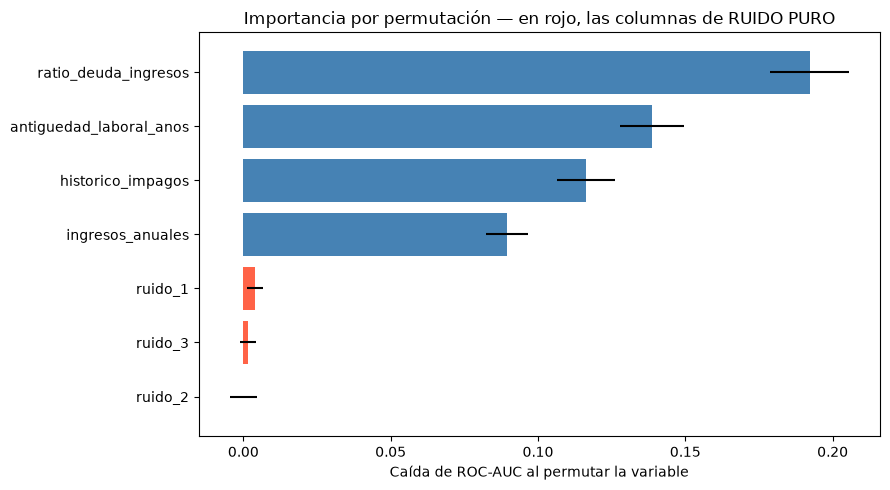

Las 3 variables de ruido deberían quedar cerca de 0: el modelo las ignoró solo.
Las que suben son exactamente las de la regla de negocio real (§1).


In [15]:
modelo_final = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=5,
    eval_metric="logloss", random_state=42, n_jobs=-1,
).fit(X_tr, y_tr)

imp = permutation_importance(
    modelo_final, X_te, y_te, n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1
)
orden = imp.importances_mean.argsort()

plt.figure(figsize=(9, 5))
colores = ["tomato" if "ruido" in X_df.columns[i] else "steelblue" for i in orden]
plt.barh(X_df.columns[orden], imp.importances_mean[orden], xerr=imp.importances_std[orden],
         color=colores)
plt.xlabel("Caída de ROC-AUC al permutar la variable")
plt.title("Importancia por permutación — en rojo, las columnas de RUIDO PURO")
plt.tight_layout()
plt.show()

print("Las 3 variables de ruido deberían quedar cerca de 0: el modelo las ignoró solo.")
print("Las que suben son exactamente las de la regla de negocio real (§1).")

## 10. Prueba final sobre datos reales

Todo lo anterior usa datos sintéticos (para conocer la verdad). Cerramos con un
dataset **real** que viene incluido en scikit-learn (sin descargas): diagnóstico
de cáncer de mama, 569 pacientes × 30 variables numéricas. Tabular puro y
pequeño — justo el terreno donde 1.2.5 dice que hoy hay competencia real.

**Anticipa el resultado antes de ejecutar:** 30 variables numéricas continuas,
sin nulos, sin categóricas, todas de escalas comparables y muy correlacionadas
con el objetivo. Según lo que acabamos de aprender en §8-bis, esto es terreno
**favorable a la red**, no a los árboles. Comprobémoslo.

In [16]:
datos = load_breast_cancer()
Xr, yr = datos.data, datos.target
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=42, stratify=yr)

reales = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "MLP (normalizada)": make_pipeline(
        StandardScaler(), MLPClassifier((64, 32), max_iter=2000, random_state=42)
    ),
}

filas = []
for nombre, m in reales.items():
    t0 = time.perf_counter()
    m.fit(Xr_tr, yr_tr)
    filas.append(
        {
            "Modelo": nombre,
            "Accuracy": round(m.score(Xr_te, yr_te), 4),
            "ROC-AUC": round(roc_auc_score(yr_te, m.predict_proba(Xr_te)[:, 1]), 4),
            "Entrenar (s)": round(time.perf_counter() - t0, 3),
        }
    )

pd.DataFrame(filas).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

,Modelo,Accuracy,ROC-AUC,Entrenar (s)
0,MLP (normalizada),0.972,0.9960,0.609
1,Random Forest,0.958,0.9949,4.678
2,XGBoost,0.965,0.9945,2.342
3,LightGBM,0.965,0.9927,14.481


## Conclusiones

Lo que hemos comprobado, y no solo leído:

1. **Un árbol se lee**; recupera la regla de negocio casi literalmente (§2).
2. **Un árbol solo sobreajusta**: la profundidad es el mando de sesgo/varianza (§3).
3. **Bagging reduce la varianza** ~un orden de magnitud entre semillas (§4).
4. **El boosting es descenso de gradiente**: lo escribimos en 15 líneas y la
   pérdida baja árbol a árbol, igual que en una red (§5 → docs 1.1.2).
5. **Los árboles cortan en escalones**, las redes suavizan (§6).
6. **Los árboles no extrapolan**: se quedan planos fuera del rango visto (§7).
7. **Ignora solo las variables de ruido** y permite explicar cada decisión (§9).

### La lección más importante (y la que no esperábamos)

En **datos limpios** (§8 y §10) la red **empata o gana** al boosting. La ventaja
de los árboles solo aparece con datos **irregulares** (§8-bis): asimetrías
fuertes, nulos con patrón, categóricas de alta cardinalidad y ruido abundante.

Es decir: **"los árboles ganan en tabular" no es una ley, es un enunciado
condicionado a las propiedades del dataset** (McElfresh et al., 2023 → docs
1.2.5). Un notebook que solo usara datos de juguete te habría hecho creer lo
contrario — y esa es justamente la trampa de la que advierte la teoría.

Lo que sí se sostiene en **todos** los experimentos es el **coste**: el boosting
llegó a su resultado entre **3× y 200× más rápido** según el caso, en CPU y sin
ajustar un solo hiperparámetro. Cuando la métrica empata, decide la ingeniería.

### Para seguir

- [ ] Sustituir el dataset sintético por uno propio del caso de uso de la tesis.
- [ ] Repetir §8 con `TabPFN` o `TabICL` y comprobar el vuelco de 2026 (docs 1.2.5).
- [ ] Medir latencia de inferencia por fila: ¿bajas de 2 ms en CPU? (docs 1.2.5).
- [ ] Probar `SecureBoost`/`FedTree`: ¿cómo cambia esto al federar? (docs 1.2.8).

**Teoría relacionada:** `docs/01-fundamentos/01-que-es-y-de-donde-viene/1.2-machine-learning-antes-del-dl.md`